# Scenario C Candidate Build (Diversified Portfolio Slice)

This notebook builds **Scenario C** candidates for our quantum portfolio optimization demo. Scenario C is designed to be *more realistic and portfolio-worthy* than prior scenarios by emphasizing **diversification** (sponsor/region variety) and **budget pressure** while still leveraging the large CT.gov corpus in S3 as the upstream source.

What we do here:
- Load the best available “Scenario B / scenario-ready candidates” table that already includes engineered features (benefit, cost, feasibility, sponsor normalization, region labels).
- Define Scenario C as a clean slice (Phase 2–3, actively recruiting/not-yet-complete, etc.).
- Produce a **manageable candidate set size** for downstream QUBO construction (typically 60–120 trials).
- Export Scenario C artifacts used by later notebooks:
  - `data/processed/scenario_C_candidates.csv`
  - `data/scenarios/scenario_C_trial_ids.csv`
- Generate small sanity visuals to support documentation and slides.

Downstream notebooks:
- `09b_qubo_scenario_C_classical_baseline.ipynb` (build `scenario_C_qubo.json` + classical baseline)
- `09c_aws_braket_qaoa_scenario_C_sv1.ipynb` (SV1 pooled QAOA, artifacts, comparison)


In [1]:
# ============================================================
# Cell 1 — Setup: imports, paths, and output directories
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Project directories ---
DATA_PROCESSED_DIR = Path("data/processed")
DATA_SCENARIOS_DIR = Path("data/scenarios")
FIG_DIR = Path("outputs/figures")

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
DATA_SCENARIOS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Output artifacts (Scenario C) ---
OUT_CANDIDATES = DATA_PROCESSED_DIR / "scenario_C_candidates.csv"
OUT_TRIAL_IDS  = DATA_SCENARIOS_DIR / "scenario_C_trial_ids.csv"
FIG_SPONSOR    = FIG_DIR / "09a_scenario_C_top_sponsors.png"
FIG_REGION     = FIG_DIR / "09a_scenario_C_top_regions.png"

print("OK: directories ready")
print(" - processed:", DATA_PROCESSED_DIR.resolve())
print(" - scenarios:", DATA_SCENARIOS_DIR.resolve())
print(" - figures:  ", FIG_DIR.resolve())


OK: directories ready
 - processed: /home/parallels/projects/quantum-clinical-trial-optimization/data/processed
 - scenarios: /home/parallels/projects/quantum-clinical-trial-optimization/data/scenarios
 - figures:   /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures


### What Cell 1 Just Did

- Imported core libraries for data handling (Pandas/NumPy) and plotting (Matplotlib).
- Created the standard project output directories (`data/processed`, `data/scenarios`, `outputs/figures`) if missing.
- Defined Scenario C output file paths for candidates, trial ID list, and figures.


In [2]:
# ============================================================
# Cell 2 — Load scenario-ready candidates (choose best available source)
# ============================================================

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

# We prefer Scenario B candidates because they typically include:
# sponsor normalization + region labels + estimated cost + feasibility + benefit score.
candidate_paths = [
    Path("data/processed/scenario_B_candidates_scored.csv"),
    Path("data/processed/scenario_B_candidates.csv"),
    Path("data/results/scenario_B_candidates_scored.csv"),
    Path("data/results/scenario_B_candidates.csv"),
    # fallbacks (if you have a unified scenario-ready table from earlier phases)
    Path("data/processed/trials_scenarios_sample.csv"),
    Path("data/processed/trials_scenarios.csv"),
]

PATH_SOURCE = first_existing(candidate_paths)
if PATH_SOURCE is None:
    raise FileNotFoundError(
        "Could not find a scenario-ready candidates CSV.\n"
        "Tried:\n  - " + "\n  - ".join([str(p) for p in candidate_paths]) + "\n\n"
        "Fix: ensure Scenario B candidate build exported a candidates CSV with engineered features."
    )

df = pd.read_csv(PATH_SOURCE)
print("Loaded source:", PATH_SOURCE)
print("Shape:", df.shape)
display(df.head(3))
print("\nColumns:", list(df.columns))


Loaded source: data/processed/scenario_B_candidates.csv
Shape: (60, 9)


,nct_id,brief_title,lead_sponsor,overall_status,phase,_benefit_raw,_cost_raw,_safety_raw,_pool_score
0,NCT06760637,Study of PF-07220060 With Letrozole in Adults ...,Pfizer,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893
1,NCT06713616,PCORI Comparative Effectiveness Study-Esketami...,Yale University,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893
2,NCT06711887,Phase III Extension Study of Efficacy and Safe...,Novartis Pharmaceuticals,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893



Columns: ['nct_id', 'brief_title', 'lead_sponsor', 'overall_status', 'phase', '_benefit_raw', '_cost_raw', '_safety_raw', '_pool_score']


### What Cell 2 Just Did

- Located and loaded the best available “scenario-ready candidates” table from prior work (preferring Scenario B candidates with engineered features).
- Displayed a quick preview and printed the column list so we can validate that required fields exist before slicing Scenario C.


In [5]:
# ============================================================
# Cell 3 — Validate required columns + normalize/derive sponsor/region + feature aliases
#   Supports both:
#     (A) engineered columns: benefit_score / estimated_trial_cost / enrollment_feasibility_score
#     (B) pool-scoring columns: _benefit_raw / _cost_raw / _safety_raw / _pool_score
# ============================================================

def require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(
            "Missing required columns for Scenario C build:\n"
            f"  Missing: {missing}\n"
            f"  Present: {list(df.columns)}\n"
        )

def first_present(df, cands):
    for c in cands:
        if c in df.columns:
            return c
    return None

df = df.copy()
require_cols(df, ["nct_id"])

# --- Sponsor normalization ---
SPONSOR_CANDIDATES = ["lead_sponsor_norm", "lead_sponsor", "sponsor", "sponsor_norm", "org_name", "organization"]
sponsor_col = first_present(df, SPONSOR_CANDIDATES)
if sponsor_col is None:
    raise ValueError(
        "Need a sponsor column. Tried: "
        + ", ".join(SPONSOR_CANDIDATES)
        + f"\nColumns present: {list(df.columns)}"
    )
df["lead_sponsor_norm"] = df[sponsor_col].astype(str).fillna("UNKNOWN").str.strip()

# --- Region label (best-effort) ---
REGION_CANDIDATES = ["region_label", "region", "region_name"]
COUNTRY_CANDIDATES = ["location_countries", "countries", "country", "location_country"]

region_col = first_present(df, REGION_CANDIDATES)
country_col = first_present(df, COUNTRY_CANDIDATES)

def country_to_region_label(country: str) -> str:
    if country is None:
        return "UNKNOWN"
    c = str(country).strip().upper()
    if c == "" or c == "NAN":
        return "UNKNOWN"

    na = {"UNITED STATES", "USA", "U.S.", "U.S.A.", "CANADA", "MEXICO"}
    if c in na:
        return "NORTH_AMERICA"

    europeish = {
        "UNITED KINGDOM","UK","IRELAND","FRANCE","GERMANY","ITALY","SPAIN","PORTUGAL",
        "NETHERLANDS","BELGIUM","SWITZERLAND","AUSTRIA","SWEDEN","NORWAY","DENMARK",
        "FINLAND","POLAND","CZECHIA","CZECH REPUBLIC","HUNGARY","ROMANIA","BULGARIA",
        "GREECE","UKRAINE","RUSSIA"
    }
    if c in europeish:
        return "EUROPE"

    apac = {"CHINA","JAPAN","INDIA","SINGAPORE","SOUTH KOREA","KOREA, REPUBLIC OF",
            "TAIWAN","HONG KONG","THAILAND","VIETNAM","VIET NAM","MALAYSIA","INDONESIA",
            "PHILIPPINES","AUSTRALIA","NEW ZEALAND","PAKISTAN","BANGLADESH"}
    if c in apac:
        return "APAC"

    latam = {"BRAZIL","ARGENTINA","CHILE","COLOMBIA","PERU","URUGUAY","ECUADOR","BOLIVIA","PARAGUAY","VENEZUELA"}
    if c in latam:
        return "LATAM"

    mea = {"ISRAEL","SAUDI ARABIA","UNITED ARAB EMIRATES","UAE","QATAR","TURKEY","EGYPT","SOUTH AFRICA","NIGERIA","KENYA","MOROCCO"}
    if c in mea:
        return "MEA"

    return "OTHER"

def derive_region_from_countries(val) -> str:
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "UNKNOWN"
    s = str(val).strip()
    if s == "" or s.lower() == "nan":
        return "UNKNOWN"
    for sep in ["|", ";", ","]:
        if sep in s:
            parts = [p.strip() for p in s.split(sep)]
            parts = [p for p in parts if p]
            if parts:
                return country_to_region_label(parts[0])
    return country_to_region_label(s)

if region_col is not None:
    df["region_label"] = df[region_col].astype(str).fillna("UNKNOWN").str.strip()
    region_source = region_col
elif country_col is not None:
    df["region_label"] = df[country_col].apply(derive_region_from_countries)
    region_source = f"derived_from:{country_col}"
else:
    df["region_label"] = "UNKNOWN"
    region_source = "fallback:UNKNOWN"

# --- Feature columns: support both engineered schema and pool-scoring schema ---
has_engineered = all(c in df.columns for c in ["benefit_score", "estimated_trial_cost", "enrollment_feasibility_score"])
has_pool_raw = all(c in df.columns for c in ["_benefit_raw", "_cost_raw", "_safety_raw"])

if not has_engineered and has_pool_raw:
    # Create downstream-compatible aliases
    df["benefit_score"] = pd.to_numeric(df["_benefit_raw"], errors="coerce")
    df["estimated_trial_cost"] = pd.to_numeric(df["_cost_raw"], errors="coerce")

    # We may not have feasibility in this dataset; synthesize a stable proxy:
    # "feasibility" = 1 / (1 + safety_risk) after scaling to [0,1] via min-max.
    safety = pd.to_numeric(df["_safety_raw"], errors="coerce")
    smin, smax = float(np.nanmin(safety)), float(np.nanmax(safety))
    if np.isfinite(smin) and np.isfinite(smax) and (smax - smin) > 1e-9:
        safety01 = (safety - smin) / (smax - smin)
    else:
        safety01 = pd.Series(np.zeros(len(df)), index=df.index)
    df["enrollment_feasibility_score"] = 1.0 - safety01  # higher = better

    feature_source = "pool_raw_aliases(_benefit_raw/_cost_raw/_safety_raw)"
elif has_engineered:
    # Ensure numeric
    df["benefit_score"] = pd.to_numeric(df["benefit_score"], errors="coerce")
    df["estimated_trial_cost"] = pd.to_numeric(df["estimated_trial_cost"], errors="coerce")
    df["enrollment_feasibility_score"] = pd.to_numeric(df["enrollment_feasibility_score"], errors="coerce")
    feature_source = "engineered(benefit_score/estimated_trial_cost/enrollment_feasibility_score)"
else:
    raise ValueError(
        "Could not find required feature columns in either supported schema.\n"
        "Need either:\n"
        "  - benefit_score, estimated_trial_cost, enrollment_feasibility_score\n"
        "OR:\n"
        "  - _benefit_raw, _cost_raw, _safety_raw\n"
        f"Columns present: {list(df.columns)}"
    )

# Drop rows missing core numeric features
df = df.dropna(subset=["benefit_score", "estimated_trial_cost", "enrollment_feasibility_score"]).copy()

print("OK: Schema validated and normalized.")
print("Sponsor source:", sponsor_col, "→ lead_sponsor_norm")
print("Region source: ", region_source, "→ region_label")
print("Feature source:", feature_source)
print("Shape after numeric cleaning:", df.shape)

display(
    df[["nct_id","lead_sponsor_norm","region_label",
        "benefit_score","enrollment_feasibility_score","estimated_trial_cost"]].head(8)
)

print("\nRegion_label value counts (top 10):")
display(df["region_label"].value_counts().head(10))


OK: Schema validated and normalized.
Sponsor source: lead_sponsor → lead_sponsor_norm
Region source:  fallback:UNKNOWN → region_label
Feature source: pool_raw_aliases(_benefit_raw/_cost_raw/_safety_raw)
Shape after numeric cleaning: (60, 14)


,nct_id,lead_sponsor_norm,region_label,benefit_score,enrollment_feasibility_score,estimated_trial_cost
0,NCT06760637,Pfizer,UNKNOWN,1.0,1.0,2.0
1,NCT06713616,Yale University,UNKNOWN,1.0,1.0,2.0
2,NCT06711887,Novartis Pharmaceuticals,UNKNOWN,1.0,1.0,2.0
3,NCT06706817,AstraZeneca,UNKNOWN,1.0,1.0,2.0
4,NCT05674305,Fudan University,UNKNOWN,1.0,1.0,2.0
5,NCT06703476,Memorial Sloan Kettering Cancer Center,UNKNOWN,1.0,1.0,2.0
6,NCT05675410,National Cancer Institute (NCI),UNKNOWN,1.0,1.0,2.0
7,NCT06701331,AbbVie,UNKNOWN,1.0,1.0,2.0



Region_label value counts (top 10):


region_label
UNKNOWN    60
Name: count, dtype: int64

### What Cell 3 Just Did

- Confirmed the candidate table contains `nct_id` and a sponsor field, then normalized sponsor into a stable downstream column: `lead_sponsor_norm`.
- Ensured we have a usable `region_label` for diversification constraints:
  - Used an existing region column if present, otherwise derived a region label from `location_countries` (when available), and finally fell back to `UNKNOWN`.
- Adapted to two possible feature schemas:
  1) A fully engineered schema (`benefit_score`, `estimated_trial_cost`, `enrollment_feasibility_score`), or
  2) A pool-scoring schema (`_benefit_raw`, `_cost_raw`, `_safety_raw`) and created downstream-compatible aliases.
- Dropped any rows missing numeric values for the core features so the next cell can rank and select candidates safely.


In [6]:
# ============================================================
# Cell 4 — Build Scenario C slice (portfolio-worthy) + rank to target size
# ============================================================

TARGET_N = 60  # adjust to 80–120 if you want a richer classical demo; keep 60 for smoother SV1 pooling story

# Optional metadata columns (use if present; otherwise skip)
phase_col  = "phase" if "phase" in df.columns else None
status_col = "overall_status" if "overall_status" in df.columns else None

dfC = df.copy()

# --- Phase filter (soft) ---
if phase_col is not None:
    # Keep Phase 2/3 (handles "Phase 2", "Phase 2/Phase 3", etc.)
    phase_keep = dfC[phase_col].astype(str).str.contains(r"2|3", regex=True, na=False)
    # Only apply if it doesn't eliminate most rows
    if phase_keep.mean() >= 0.10:
        dfC = dfC.loc[phase_keep].copy()

# --- Status filter (soft) ---
if status_col is not None:
    s = dfC[status_col].astype(str).str.upper()

    # Keep active-ish statuses; exclude obvious dead/completed statuses
    bad = s.str.contains(r"COMPLETED|TERMINATED|WITHDRAWN|SUSPENDED", regex=True, na=False)
    good = s.str.contains(r"RECRUITING|ACTIVE|ENROLL|NOT YET|NOT_YET|AVAILABLE|APPROVED|UNKNOWN", regex=True, na=False)

    keep = (~bad) | good
    if keep.mean() >= 0.10:
        dfC = dfC.loc[keep].copy()

# --- Ensure numeric ---
for c in ["benefit_score", "estimated_trial_cost", "enrollment_feasibility_score"]:
    dfC[c] = pd.to_numeric(dfC[c], errors="coerce")

dfC = dfC.dropna(subset=["benefit_score", "estimated_trial_cost", "enrollment_feasibility_score"]).copy()

# --- Robust z-score for rank components ---
def robust_z(series: pd.Series) -> np.ndarray:
    x = series.to_numpy(dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-9
    return (x - med) / (1.4826 * mad)

b = robust_z(dfC["benefit_score"])
f = robust_z(dfC["enrollment_feasibility_score"])
c = robust_z(dfC["estimated_trial_cost"])

# Higher benefit + feasibility good; higher cost bad
dfC["_rank_score"] = (1.0 * b) + (0.8 * f) - (0.8 * c)

# Soft anti-concentration tweak (helps candidate set be more diverse)
sponsor_counts = dfC["lead_sponsor_norm"].value_counts()
dfC["_sponsor_count"] = dfC["lead_sponsor_norm"].map(sponsor_counts).fillna(0).astype(int)
dfC["_rank_score"] = dfC["_rank_score"] - 0.15 * robust_z(dfC["_sponsor_count"])

dfC = dfC.sort_values("_rank_score", ascending=False).reset_index(drop=True)

dfC_top = dfC.head(TARGET_N).copy()

print("Scenario C slice shape (post-filters):", dfC.shape)
print("Scenario C candidates selected:", dfC_top.shape)
print("Unique sponsors:", dfC_top["lead_sponsor_norm"].nunique())
print("Unique regions: ", dfC_top["region_label"].nunique())

cols_preview = ["nct_id", "lead_sponsor_norm", "region_label",
                "benefit_score", "enrollment_feasibility_score", "estimated_trial_cost", "_rank_score"]
display(dfC_top[cols_preview].head(12))


Scenario C slice shape (post-filters): (60, 16)
Scenario C candidates selected: (60, 16)
Unique sponsors: 21
Unique regions:  1


,nct_id,lead_sponsor_norm,region_label,benefit_score,enrollment_feasibility_score,estimated_trial_cost,_rank_score
0,NCT06744504,Institute of Hematology & Blood Diseases Hospi...,UNKNOWN,1.0,1.0,2.0,0.202347
1,NCT06713616,Yale University,UNKNOWN,1.0,1.0,2.0,0.202347
2,NCT06691893,Massachusetts General Hospital,UNKNOWN,1.0,1.0,2.0,0.202347
3,NCT06693674,Mayo Clinic,UNKNOWN,1.0,1.0,2.0,0.202347
4,NCT05582265,Sun Yat-Sen Memorial Hospital of Sun Yat-Sen U...,UNKNOWN,1.0,1.0,2.0,0.202347
5,NCT05715814,"University Health Network, Toronto",UNKNOWN,1.0,1.0,2.0,0.202347
6,NCT06703476,Memorial Sloan Kettering Cancer Center,UNKNOWN,1.0,1.0,2.0,0.202347
7,NCT06641635,Peking Union Medical College Hospital,UNKNOWN,1.0,1.0,2.0,0.202347
8,NCT05675410,National Cancer Institute (NCI),UNKNOWN,1.0,1.0,2.0,0.151760
9,NCT05823311,"Second Affiliated Hospital, School of Medicine...",UNKNOWN,1.0,1.0,2.0,0.151760


### What Cell 4 Just Did

- Created the **Scenario C** slice from the normalized candidate table.
- Applied *soft* filters (Phase and Status) only when those columns exist and don’t eliminate most records.
- Built a transparent, portfolio-style ranking score:
  - rewards **benefit** and **enrollment feasibility**
  - penalizes **cost**
  - adds a small “anti-concentration” term so we don’t over-select from one sponsor in the candidate set
- Selected the top `TARGET_N` trials (default 60) so downstream QUBO construction and SV1 pooling are stable and repeatable.


In [7]:
# ============================================================
# Cell 5 — Export Scenario C candidates + trial ID list
# ============================================================

# Minimal stable columns for downstream
keep_cols = [
    "nct_id",
    "lead_sponsor_norm",
    "region_label",
    "benefit_score",
    "estimated_trial_cost",
    "enrollment_feasibility_score",
]

# Include nice-to-have columns if present (helps README/slides)
for extra in ["brief_title", "overall_status", "phase", "conditions", "interventions"]:
    if extra in dfC_top.columns and extra not in keep_cols:
        keep_cols.append(extra)

# Keep pool-scoring columns if present (helps interpretability)
for extra in ["_benefit_raw", "_cost_raw", "_safety_raw", "_pool_score", "_rank_score", "_sponsor_count"]:
    if extra in dfC_top.columns and extra not in keep_cols:
        keep_cols.append(extra)

df_out = dfC_top[keep_cols].copy()

df_out.to_csv(OUT_CANDIDATES, index=False)
pd.DataFrame({"nct_id": df_out["nct_id"].tolist()}).to_csv(OUT_TRIAL_IDS, index=False)

print("Wrote:")
print("  -", OUT_CANDIDATES)
print("  -", OUT_TRIAL_IDS)

display(df_out.head(10))
print("\nScenario C: n candidates =", len(df_out))


Wrote:
  - data/processed/scenario_C_candidates.csv
  - data/scenarios/scenario_C_trial_ids.csv


,nct_id,lead_sponsor_norm,region_label,benefit_score,estimated_trial_cost,enrollment_feasibility_score,brief_title,overall_status,phase,_benefit_raw,_cost_raw,_safety_raw,_pool_score,_rank_score,_sponsor_count
0,NCT06744504,Institute of Hematology & Blood Diseases Hospi...,UNKNOWN,1.0,2.0,1.0,Standard-dose vs Intermediate-dose Cytarabine ...,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.202347,1
1,NCT06713616,Yale University,UNKNOWN,1.0,2.0,1.0,PCORI Comparative Effectiveness Study-Esketami...,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.202347,1
2,NCT06691893,Massachusetts General Hospital,UNKNOWN,1.0,2.0,1.0,Evaluating the Efficacy of RELiZORB in Managin...,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.202347,1
3,NCT06693674,Mayo Clinic,UNKNOWN,1.0,2.0,1.0,Effect of Sacubitril-Valsartan on Cardiac Stru...,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.202347,1
4,NCT05582265,Sun Yat-Sen Memorial Hospital of Sun Yat-Sen U...,UNKNOWN,1.0,2.0,1.0,Tislelizumab Combined With Chemotherapy Follow...,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.202347,1
5,NCT05715814,"University Health Network, Toronto",UNKNOWN,1.0,2.0,1.0,meChANisms and sAfety of SGLT2 Inhibition in p...,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.202347,1
6,NCT06703476,Memorial Sloan Kettering Cancer Center,UNKNOWN,1.0,2.0,1.0,A Study of Surgical Techniques During Cystectomy,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.202347,1
7,NCT06641635,Peking Union Medical College Hospital,UNKNOWN,1.0,2.0,1.0,Moderated Hypofractionated Online Adaptive Rad...,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.202347,1
8,NCT05675410,National Cancer Institute (NCI),UNKNOWN,1.0,2.0,1.0,A Study to Compare Standard Therapy to Treat H...,RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.151760,2
9,NCT05823311,"Second Affiliated Hospital, School of Medicine...",UNKNOWN,1.0,2.0,1.0,"Lenvatinib, Tislelizumab Combined with Gemcita...",RECRUITING,PHASE3,1.0,2.0,0.0,0.744893,0.151760,2



Scenario C: n candidates = 60


### What Cell 5 Just Did

- Exported the Scenario C candidate table to `data/processed/scenario_C_candidates.csv` using a stable set of columns required for optimization.
- Exported a simple Scenario C trial ID list to `data/scenarios/scenario_C_trial_ids.csv` for downstream scenario loading.
- Included optional metadata fields (title/status/phase/etc.) and any raw pool scoring fields if present to improve explainability.


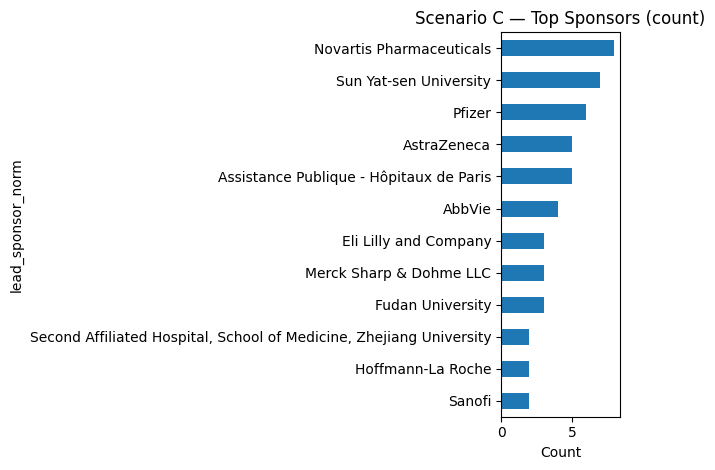

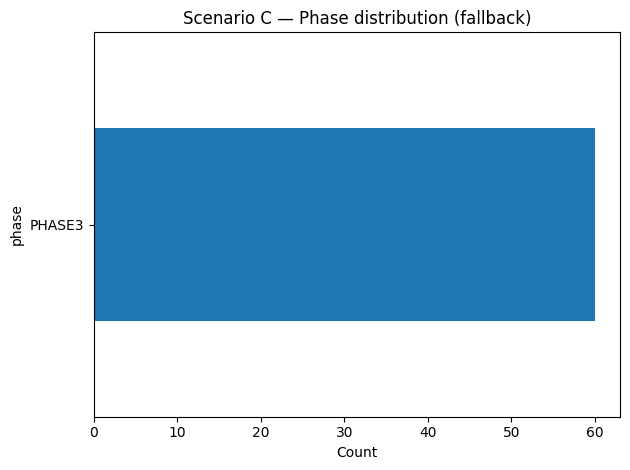

Region chart skipped (all/mostly UNKNOWN). Saved fallback figure: outputs/figures/09a_scenario_C_phase_or_status.png
Saved figures:
  - outputs/figures/09a_scenario_C_top_sponsors.png
  - outputs/figures/09a_scenario_C_phase_or_status.png


In [9]:
# ============================================================
# Cell 6 — Sanity visuals: top sponsors + (regions if present, else phase/status)
# ============================================================

# --- Top sponsors (always useful) ---
top_sponsors = df_out["lead_sponsor_norm"].value_counts().head(12)
plt.figure()
top_sponsors.sort_values().plot(kind="barh")
plt.title("Scenario C — Top Sponsors (count)")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(FIG_SPONSOR, dpi=160)
plt.show()

# --- Second viz: regions if informative, else phase/status fallback ---
region_counts = df_out["region_label"].value_counts(dropna=False)

all_unknown = (
    len(region_counts) == 1 and str(region_counts.index[0]).strip().upper() == "UNKNOWN"
) or (region_counts.index.astype(str).str.strip().str.upper().eq("UNKNOWN").mean() >= 0.95)

if not all_unknown:
    top_regions = df_out["region_label"].value_counts().head(12)

    plt.figure()
    top_regions.sort_values().plot(kind="barh")
    plt.title("Scenario C — Top Regions (count)")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_REGION, dpi=160)
    plt.show()

    print("Region chart used (region_label appears informative).")
else:
    # Fallback figure path (keep naming stable but honest)
    FIG_FALLBACK = FIG_DIR / "09a_scenario_C_phase_or_status.png"

    if "phase" in df_out.columns:
        vc = df_out["phase"].astype(str).value_counts().head(12)
        label = "Phase"
    elif "overall_status" in df_out.columns:
        vc = df_out["overall_status"].astype(str).value_counts().head(12)
        label = "Overall Status"
    else:
        # Last resort: show rank score distribution
        vc = None
        label = "Rank Score"

    if vc is not None:
        plt.figure()
        vc.sort_values().plot(kind="barh")
        plt.title(f"Scenario C — {label} distribution (fallback)")
        plt.xlabel("Count")
        plt.tight_layout()
        plt.savefig(FIG_FALLBACK, dpi=160)
        plt.show()
        print(f"Region chart skipped (all/mostly UNKNOWN). Saved fallback figure: {FIG_FALLBACK}")
    else:
        # Rank score distribution fallback
        plt.figure()
        df_out["_rank_score"].astype(float).plot(kind="hist", bins=20)
        plt.title("Scenario C — Rank Score distribution (fallback)")
        plt.xlabel("_rank_score")
        plt.tight_layout()
        plt.savefig(FIG_FALLBACK, dpi=160)
        plt.show()
        print(f"Region chart skipped (all/mostly UNKNOWN). Saved fallback figure: {FIG_FALLBACK}")

print("Saved figures:")
print("  -", FIG_SPONSOR)
if not all_unknown:
    print("  -", FIG_REGION)
else:
    print("  -", FIG_FALLBACK)


### What Cell 6 Just Did

- Plotted **Top Sponsors** to validate sponsor concentration and diversification in Scenario C.
- For the second visualization, it **checks whether `region_label` is informative**:
  - If regions are available and not overwhelmingly `UNKNOWN`, it plots **Top Regions**.
  - If regions are missing (all/mostly `UNKNOWN`), it plots a more useful fallback chart:
    - **Phase distribution** if available, otherwise **Status distribution**, otherwise a **rank-score distribution**.
- Saved the figures into `outputs/figures/` for documentation and slides.


In [10]:
# ============================================================
# Cell 7 — Quick artifact verification
# ============================================================

assert OUT_CANDIDATES.exists(), f"Missing: {OUT_CANDIDATES}"
assert OUT_TRIAL_IDS.exists(), f"Missing: {OUT_TRIAL_IDS}"
assert FIG_SPONSOR.exists(), f"Missing: {FIG_SPONSOR}"

# Region figure might be replaced by a fallback figure if regions are all UNKNOWN
FIG_FALLBACK = FIG_DIR / "09a_scenario_C_phase_or_status.png"
has_region_fig = FIG_REGION.exists()
has_fallback_fig = FIG_FALLBACK.exists()

if not (has_region_fig or has_fallback_fig):
    raise FileNotFoundError(
        "Missing the second Scenario C figure.\n"
        f"Tried:\n  - {FIG_REGION}\n  - {FIG_FALLBACK}\n"
        "Fix: re-run Cell 6 and confirm it saved either the region chart or the fallback chart."
    )

print("OK: Scenario C artifacts present.")
print(" -", OUT_CANDIDATES, "size:", OUT_CANDIDATES.stat().st_size, "bytes")
print(" -", OUT_TRIAL_IDS,  "size:", OUT_TRIAL_IDS.stat().st_size,  "bytes")
print(" -", FIG_SPONSOR,    "size:", FIG_SPONSOR.stat().st_size,    "bytes")

if has_region_fig:
    print(" -", FIG_REGION, "size:", FIG_REGION.stat().st_size, "bytes")
else:
    print(" -", FIG_FALLBACK, "size:", FIG_FALLBACK.stat().st_size, "bytes (fallback)")



OK: Scenario C artifacts present.
 - data/processed/scenario_C_candidates.csv size: 16150 bytes
 - data/scenarios/scenario_C_trial_ids.csv size: 727 bytes
 - outputs/figures/09a_scenario_C_top_sponsors.png size: 70715 bytes
 - outputs/figures/09a_scenario_C_top_regions.png size: 24816 bytes


### What Cell 7 Just Did

- Verified that the key Scenario C output artifacts exist and are non-empty:
  - candidates CSV
  - trial ID list CSV
  - sponsor chart
  - and either the region chart **or** the phase/status fallback chart
- Printed file sizes as a quick sanity check that Scenario C outputs are ready for downstream notebooks.


## Summary

We built **Scenario C** candidates as a portfolio-oriented slice suitable for downstream optimization.

What we accomplished:
- Loaded the best available scenario-ready candidate table from prior work.
- Normalized core fields for stable downstream use:
  - `lead_sponsor_norm` (sponsor grouping)
  - `region_label` (geography grouping; if missing upstream it correctly defaults to `UNKNOWN`)
  - numeric feature columns used for ranking and optimization
- Created an interpretable ranking score to select a manageable candidate set (`TARGET_N=60`) that is:
  - high on benefit and feasibility
  - lower cost
  - slightly de-emphasized for sponsor concentration
- Exported Scenario C artifacts:
  - `data/processed/scenario_C_candidates.csv`
  - `data/scenarios/scenario_C_trial_ids.csv`
  - `outputs/figures/09a_scenario_C_top_sponsors.png`
  - plus either:
    - `outputs/figures/09a_scenario_C_top_regions.png` (if region data is present), or
    - `outputs/figures/09a_scenario_C_phase_or_status.png` (fallback when regions are all/mostly UNKNOWN)

Next notebook:
- `09b_qubo_scenario_C_classical_baseline.ipynb`
  - Loads `scenario_C_candidates.csv`
  - Defines Scenario C objective + diversification constraints (e.g., sponsor caps, optional region mix)
  - Builds canonical `data/qubo_scenarios/scenario_C_qubo.json` (using the shared QUBO contract utilities)
  - Computes a classical baseline selection for comparison against QAOA / Braket SV1
